In [ ]:
pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 31.7 MB/s eta 0:00:00


In [ ]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
os.chdir('/content/drive/My Drive/')
print(os.getcwd())

/content/drive/My Drive


In [ ]:

main_dir = "PP_DATA2"
categories = ["Before_Fire", "Fire", "After_Fire", "No_Fire"]

# Storage for images, labels, and min/max values per category
X, y = [], []
category_min_max = {category: {"min": float("inf"), "max": float("-inf")} for category in categories}

for category in categories:
    folder_path = os.path.join(main_dir, category)
    for file in os.listdir(folder_path):
        if file.endswith(".tif"):
            file_path = os.path.join(folder_path, file)

            with rasterio.open(file_path) as dataset:
                thermal_band = dataset.read(11)  # Read the thermal band

                # Update category-specific min/max for displaying tiles on non RGB bands to scale a heatmap

                category_min_max[category]["min"] = min(category_min_max[category]["min"], thermal_band.min())
                category_min_max[category]["max"] = max(category_min_max[category]["max"], thermal_band.max())

                # Normalize the band
                thermal_band = (thermal_band - thermal_band.min()) / (thermal_band.max() - thermal_band.min())

                X.append(thermal_band)
                y.append(categories.index(category))

X = np.array(X)
y = np.array(y)

print(f"Dataset shape: {X.shape}, Labels shape: {y.shape}")
for category, min_max in category_min_max.items():
    print(f"{category}: Min = {min_max['min']}, Max = {min_max['max']}")




Dataset shape: (284, 84, 84), Labels shape: (284,)
Before_Fire: Min = 19292.0, Max = 26615.0
Fire: Min = 19605.0, Max = 28147.0
After_Fire: Min = 16718.0, Max = 20017.0
No_Fire: Min = 11733.0, Max = 21109.0


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(84, 84, 1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print(model.summary())


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 82, 82, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 41, 41, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 39, 39, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 19, 19, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 17, 17, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,292 (18.42 MB)

 Trainable params: 4,828,292 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Reshape for CNN (Add channel dimension)
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

# Train the model
model.fit(X_train, y_train, epochs=25, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 457ms/step - accuracy: 0.2820 - loss: 1.8624 - val_accuracy: 0.4070 - val_loss: 1.3569
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 490ms/step - accuracy: 0.5182 - loss: 1.3241 - val_accuracy: 0.4535 - val_loss: 1.2636
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 502ms/step - accuracy: 0.4940 - loss: 1.1844 - val_accuracy: 0.4186 - val_loss: 1.2310
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 415ms/step - accuracy: 0.4569 - loss: 1.1676 - val_accuracy: 0.3721 - val_loss: 1.2182
Epoch 5/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 646ms/step - accuracy: 0.4447 - loss: 1.1163 - val_accuracy: 0.4419 - val_loss: 1.1771
Epoch 6/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 411ms/step - accuracy: 0.5042 - loss: 1.0366 - val_accuracy: 0.5000 - val_loss: 1.0093
Epoch 7/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 407ms/step - accuracy: 0.6138 - loss: 0.8601 - val_accuracy: 0.4767 - val_loss: 1.1973
Epoch 8/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 518ms/step - accuracy: 0.6364 - loss: 0.8883 - val_accuracy: 0.5465 - val_loss:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━

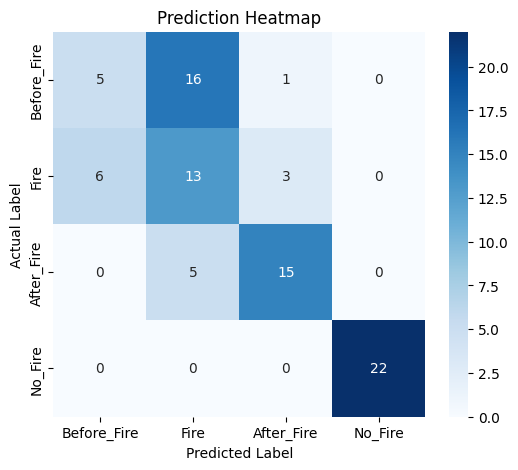

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Store predictions and actual labels
y_pred = []
y_actual = []

# Iterate over the entire test dataset
for index in range(len(X_test)):
    prediction = model.predict(X_test[index:index+1])
    predicted_label = np.argmax(prediction)  # Get index of highest probability
    actual_label = y_test[index]

    y_pred.append(predicted_label)
    y_actual.append(actual_label)

# Convert lists to arrays
y_pred = np.array(y_pred)
y_actual = np.array(y_actual)

# Create confusion matrix
conf_matrix = confusion_matrix(y_actual, y_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=categories, yticklabels=categories)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Prediction Heatmap")
plt.show()

